### Analiza danych Citi Bike
Sprawdzenie charakterystyki wypożyczeń po nałożeniu pogody i pandemii

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ustawienie estetycznego stylu wykresów
sns.set_theme(style="whitegrid")

print("rozpoczęcie wczytywania...")
# Wczytanie danych (pamiętaj, że skrypt agregujący Citi Bike musi się najpierw skończyć!)
bike_df = pd.read_csv('data/processed/citi_bike_daily.csv')
print("rowery wczytane...")
weather_df = pd.read_csv('data/processed/nyc_weather.csv')
print("pogoda wczytane...")
# Konwersja kolumn z datą na typ Datetime (bardzo ważne do wykresów osi czasu)
bike_df['date'] = pd.to_datetime(bike_df['date'])
weather_df['date'] = pd.to_datetime(weather_df['date'])

print("Dane Citi Bike wczytane. Liczba dni:", len(bike_df))
print("Dane pogodowe wczytane. Liczba dni:", len(weather_df))

rozpoczęcie wczytywania...
rowery wczytane...
pogoda wczytane...
Dane Citi Bike wczytane. Liczba dni: 1460
Dane pogodowe wczytane. Liczba dni: 1461


In [12]:
# Łączymy dane po kolumnie 'date'
df = pd.merge(bike_df, weather_df, on='date', how='inner')

# Inżynieria cech: wyciągamy rok, miesiąc i nazwę dnia tygodnia
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.day_name()

print(f"Połączono pomyślnie! Mamy {df.shape[0]} dni z pełnymi danymi (rowery + pogoda).")
df.head()

Połączono pomyślnie! Mamy 1460 dni z pełnymi danymi (rowery + pogoda).


,date,total_rides,temp_max_C,temp_min_C,precipitation_mm,year,month,day_of_week
0,2019-01-01,21962,14.5,4.4,7.5,2019,1,Tuesday
1,2019-01-02,37797,3.8,-0.3,0.0,2019,1,Wednesday
2,2019-01-03,41676,7.2,0.3,0.0,2019,1,Thursday
3,2019-01-04,43922,8.1,-1.1,0.0,2019,1,Friday
4,2019-01-05,17432,6.8,3.9,20.0,2019,1,Saturday


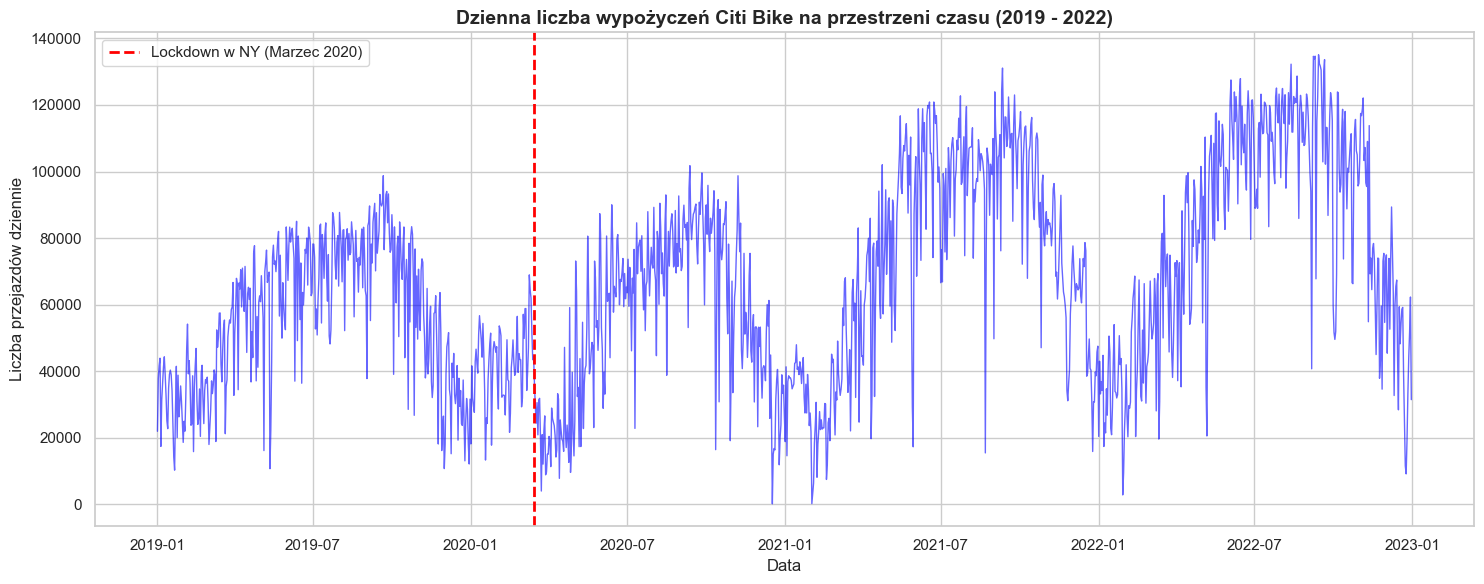

In [13]:
plt.figure(figsize=(15, 6))

sns.lineplot(data=df, x='date', y='total_rides', linewidth=1, color='blue', alpha=0.6, )

plt.axvline(pd.to_datetime('2020-03-15'), color='red', linestyle='--', linewidth=2, label='Lockdown w NY (Marzec 2020)')

plt.title('Dzienna liczba wypożyczeń Citi Bike na przestrzeni czasu (2019 - 2022)', fontsize=14, fontweight='bold')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Liczba przejazdów dziennie', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('wypozyczenia_w_czasie.png', dpi = 300, bbox_inches='tight')
plt.show()

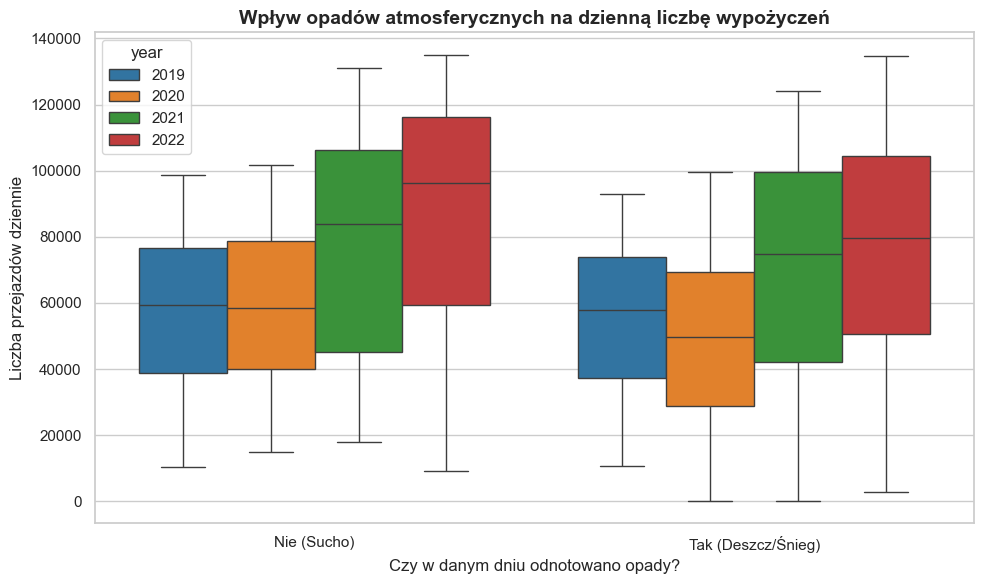

In [14]:
plt.figure(figsize=(10, 6))

# Tworzymy szybką kolumnę zero-jedynkową: czy padało (opady > 0 mm)
df['czy_padalo'] = df['precipitation_mm'] > 0.0

# Wykres pudełkowy (Boxplot) porównujący dni deszczowe i suche w podziale na lata
sns.boxplot(data=df, x='czy_padalo', y='total_rides', hue='year', palette='tab10')

plt.title('Wpływ opadów atmosferycznych na dzienną liczbę wypożyczeń', fontsize=14, fontweight='bold')
plt.xlabel('Czy w danym dniu odnotowano opady?', fontsize=12)
plt.ylabel('Liczba przejazdów dziennie', fontsize=12)
plt.xticks([0, 1], ['Nie (Sucho)', 'Tak (Deszcz/Śnieg)'])
plt.tight_layout()
plt.savefig('opady_a_popularnosc.png', dpi = 300, bbox_inches='tight')

plt.show()

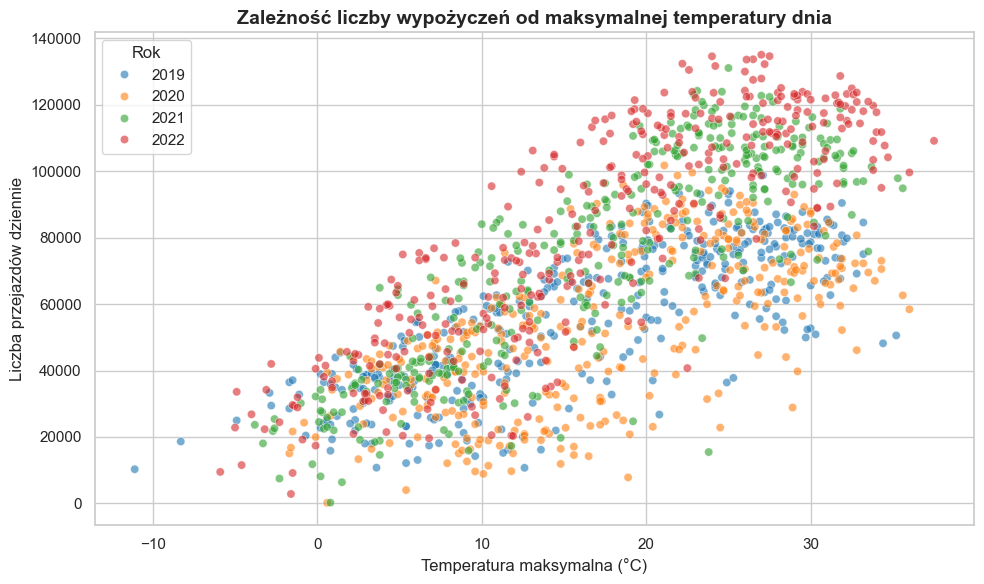

In [15]:
plt.figure(figsize=(10, 6))

# Wykres punktowy (Scatter plot), gdzie punkty kolorujemy w zależności od roku
sns.scatterplot(data=df, x='temp_max_C', y='total_rides', hue='year', palette='tab10', alpha=0.6)

plt.title('Zależność liczby wypożyczeń od maksymalnej temperatury dnia', fontsize=14, fontweight='bold')
plt.xlabel('Temperatura maksymalna (°C)', fontsize=12)
plt.ylabel('Liczba przejazdów dziennie', fontsize=12)
plt.legend(title='Rok')
plt.tight_layout()
plt.savefig('zaleznosc_od_temp.png', dpi = 300, bbox_inches='tight')
plt.show()

## anomaly detection

In [16]:
from sklearn.ensemble import IsolationForest

print("Uruchamianie detekcji anomalii...")

# Wybieramy cechy, w których szukamy anomalii (ruch + pogoda)
features_anomaly = ['total_rides', 'temp_max_C', 'precipitation_mm']

# Tworzymy czystą kopię danych bez braków
df_anom = df.dropna(subset=features_anomaly).copy()

# Inicjalizacja modelu - szukamy 2% najdziwniejszych dni
iso_forest = IsolationForest(contamination=0.02, random_state=42)

# Model zwraca 1 dla normalnych dni i -1 dla anomalii
df_anom['is_anomaly'] = iso_forest.fit_predict(df_anom[features_anomaly])

# Wyciągamy tylko anomalie do osobnej tabeli
anomalies = df_anom[df_anom['is_anomaly'] == -1]

print(f"Algorytm przeanalizował dane i wykrył {len(anomalies)} anomalnych dni.")

Uruchamianie detekcji anomalii...
Algorytm przeanalizował dane i wykrył 30 anomalnych dni.


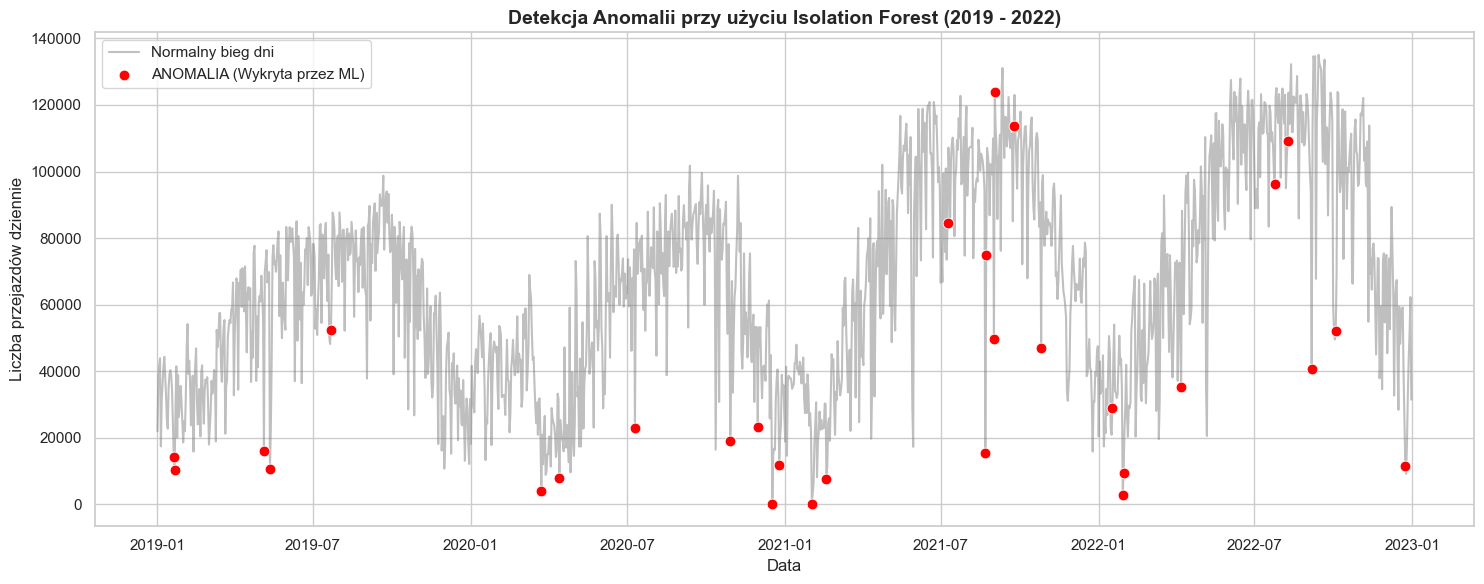


Top 10 najbardziej anomalnych dni wykrytych przez model:
           date  total_rides  temp_max_C  precipitation_mm
716  2020-12-17          180         0.6              17.9
762  2021-02-01          241         0.8              38.6
1123 2022-01-29         2848        -1.6              18.6
447  2020-03-23         4015         5.4              29.6
778  2021-02-18         7493        -2.3              13.2
468  2020-04-13         7825        18.9              41.5
1124 2022-01-30         9486        -5.9               0.0
20   2019-01-21        10291       -11.1               0.0
131  2019-05-12        10729        12.6              29.2
1452 2022-12-24        11542        -4.6               0.0
724  2020-12-25        11897        14.8              35.8
19   2019-01-20        14249         9.6              30.9
963  2021-08-22        15466        23.8              67.3
124  2019-05-05        16169        13.6              36.0
667  2020-10-29        19148        12.6              37.

In [17]:
plt.figure(figsize=(15, 6))

# Rysujemy normalny ruch w tle (szary/niebieski)
sns.lineplot(data=df_anom, x='date', y='total_rides', color='gray', alpha=0.5, label='Normalny bieg dni')

# Nakładamy anomalie jako czerwone kropki
sns.scatterplot(data=anomalies, x='date', y='total_rides', color='red', s=60, label='ANOMALIA (Wykryta przez ML)', zorder=5)

plt.title('Detekcja Anomalii przy użyciu Isolation Forest (2019 - 2022)', fontsize=14, fontweight='bold')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Liczba przejazdów dziennie', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()

# Wyświetlamy listę tych dni posortowaną od najmniejszej liczby przejazdów
print("\nTop 10 najbardziej anomalnych dni wykrytych przez model:")
print(anomalies[['date', 'total_rides', 'temp_max_C', 'precipitation_mm']].sort_values(by='total_rides').head(20))

##  Śledztwo Historyczne: Pełna Analiza Anomalii Wykrytych przez ML

Algorytm **Isolation Forest** automatycznie przeanalizował relacje między liczbą wypożyczeń, temperaturą a opadami i wskazał dni, które najbardziej odbiegały od normy. Przeprowadzona weryfikacja historyczna potwierdza bezbłędne działanie modelu w wykrywaniu zjawisk ekstremalnych.

### 1. Katastrofalne Ataki Ziemi i Paraliż Pogodowy
Model jako najsilniejsze anomalie wskazał dni, w których ruch w Nowym Jorku praktycznie przestał istnieć z powodu ekstremalnych blizzardów i mrozów:
* **2020-12-17 (180 przejazdów):** Historyczna mega-śnieżyca (*Nor'easter*). Na miasto spadło ponad 25 cm śniegu w kilka godzin. Burmistrz ogłosił stan wyjątkowy.
* **2021-02-01 (241 przejazdów):** Śnieżyca *Orlena*. Wiatr wiejący 80 km/h oraz gigantyczne zaspy wymusiły zamknięcie transportu publicznego.
* **2022-01-29 (2848 przejazdów) & 2022-01-30 (9486 przejazdów):** Atak potężnego blizzardu wywołanego przez *Bombowy Cyklon Kenan*. Śnieg sypał w tempie 5 cm na godzinę przy mrozie do -6°C.
* **2019-01-21 (10 291 przejazdów) & 2019-01-20 (14 249 przejazdów):** Ekstremalna fala arktycznych mrozów (*Flash Freeze*). Maksymalna temperatura w dzień spadła do **-11.1°C** (odczuwalna poniżej -20°C).

### 2. Efekt Świąteczny (Anomalie Kalendarzowe)
To jedno z najciekawszych odkryć modelu. Ludzie w święta zostają w domach, co dla algorytmu jest oczywistą anomalią (zwłaszcza gdy pogoda jest dobra, a ruch drastycznie spada):
* **2022-12-24 (11 542 przejazdy):** Wigilia Bożego Narodzenia połączona z nagłym uderzeniem fali mrozu (-4.6°C).
* **2020-12-25 (11 897 przejazdów):** **Boże Narodzenie.** Zwróćmy uwagę na temperaturę: aż **14.8°C**! W tak ciepły dzień model spodziewałby się rekordów (ponad 80 tys. przejazdów), tymczasem Nowy Jork świętował w domach. Model wykrył to jako potężne odstępstwo kulturowe od wzorca pogodowego.

### 3. Ekstremalne Letnie i Jesienne Ulewy (Huragany i Cyklony)
Wykryte dni charakteryzują się bardzo wysoką temperaturą, w którą normalnie system biłby rekordy, ale potężna ściana deszczu całkowicie zatrzymała ruch:
* **2021-08-22 (15 466 przejazdów):** Środek lata, gorąco (23.8°C), ale aż **67.3 mm opadów**! To dzień, w którym w Nowy Jork uderzył **Huragan Henri**, zalewając stacje metra i ulice.
* **2022-04-07 (35 322 przejazdy):** Wiosenny dzień storpedowany przez gigantyczną ulewę (58.2 mm) i podtopienia.
* **2019-05-05 (16 169) & 2019-05-12 (10 729):** Dwa majowe weekendy z rzędu (w tym Dzień Matki w USA), które zostały całkowicie zniszczone przez ulewne, całodniowe deszcze (ponad 30 mm opadów).
* **2020-10-29 (19 148) & 2020-11-30 (23 330):** Przejścia niszczycielskich frontów burzowych i ulew (resztki tropikalnego cyklonu Zeta w październiku).

### 4. COVID-19 i Szok Pandemiczny
* **2020-03-23 (4015 przejazdów):** Pierwszy oficjalny dzień pełnego lockdownu stanowego pod hasłem *"New York State on Pause"*. Nakazano bezwzględne pozostanie w domach.
* **2020-04-13 (7825 przejazdów):** Poniedziałek wielkanocny w samym szczycie pierwszej fali zgonów na COVID-19 w NY. Mimo pięknej pogody (18.9°C), miasto-widmo wygenerowało ułamek normalnego ruchu.
* **2020-07-10 (22 833 przejazdy):** Środek wakacji, idealne 24.5°C. W normalnych warunkach byłoby tu ponad 90 tys. przejazdów. Ruch został jednak zduszony przez uderzenie burzy tropikalnej Fay oraz obowiązujące restrykcje pandemiczne.

---
**Wniosek końcowy:** Algorytm Isolation Forest spisał się genialnie. Bez jakiejkolwiek wiedzy o kalendarzu, świętach religijnych czy historii katastrof naturalnych, wyłącznie na podstawie matematycznych zależności między pogodą a ruchem, bezbłędnie wskazał kluczowe momenty w historii Nowego Jorku z lat 2019-2022.

C:\Users\antek\AppData\Local\Temp\ipykernel_10732\4019099871.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resilience.reset_index(), x='year', y='Resilience_Index_%', palette='coolwarm')


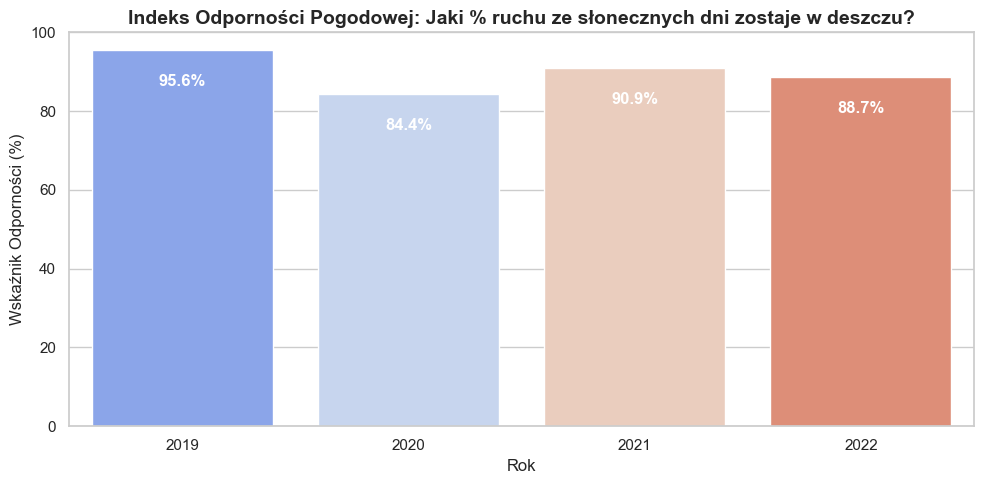

In [18]:
# Tworzymy kolumnę True/False informującą czy w danym dniu padało
df['is_raining'] = df['precipitation_mm'] > 0

# Dzielimy dni na suche i deszczowe, a potem liczymy średnią dla każdego roku
resilience = df.groupby(['year', 'is_raining'])['total_rides'].mean().unstack()

# Liczymy nasz indeks: Jaki % ruchu z suchego dnia udaje się utrzymać w deszczowy dzień?
resilience['Resilience_Index_%'] = (resilience[True] / resilience[False]) * 100

plt.figure(figsize=(10, 5))
sns.barplot(data=resilience.reset_index(), x='year', y='Resilience_Index_%', palette='coolwarm')

plt.title('Indeks Odporności Pogodowej: Jaki % ruchu ze słonecznych dni zostaje w deszczu?', fontsize=14, fontweight='bold')
plt.xlabel('Rok', fontsize=12)
plt.ylabel('Wskaźnik Odporności (%)', fontsize=12)
plt.ylim(0, 100)

for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() - 8),
                ha='center', va='center', color='white', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

C:\Users\antek\AppData\Local\Temp\ipykernel_10732\4267138268.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_days.reset_index(), x='year', y='Udział Weekendów (%)', palette='YlOrBr')


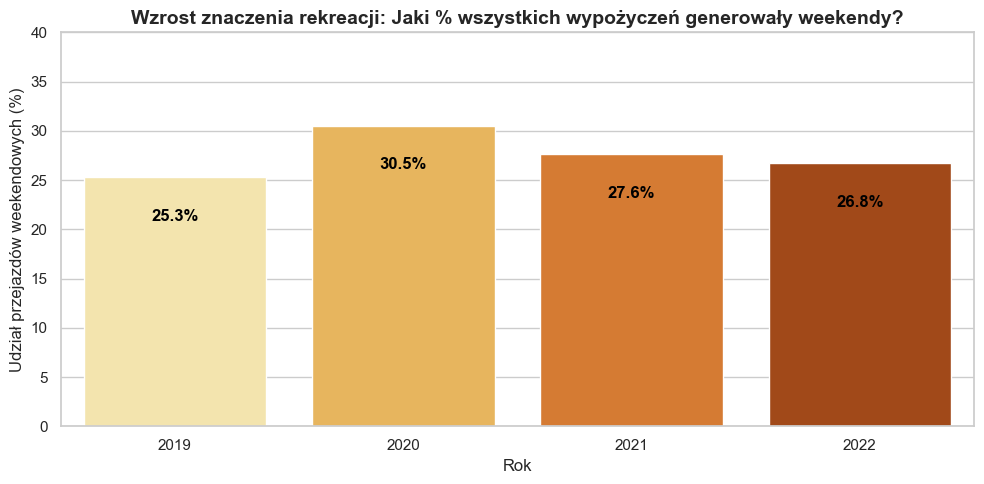

In [19]:
# Sprawdzamy czy dany dzień to weekend (Sobota=5, Niedziela=6)
df['is_weekend'] = df['date'].dt.dayofweek.isin([5, 6])
df['day_type'] = df['is_weekend'].map({True: 'Weekend (Rekreacja)', False: 'Dzień Roboczy (Kołnierzyki)'})

# Sumujemy liczbę przejazdów w podziale na lata i typ dnia
df_days = df.groupby(['year', 'day_type'])['total_rides'].sum().unstack()

# Obliczamy udział procentowy weekendów w całym ruchu w danym roku
df_days['Udział Weekendów (%)'] = (df_days['Weekend (Rekreacja)'] / (df_days['Weekend (Rekreacja)'] + df_days['Dzień Roboczy (Kołnierzyki)'])) * 100

# Rysujemy wykres pokazujący jak rósł udział rekreacji
plt.figure(figsize=(10, 5))
sns.barplot(data=df_days.reset_index(), x='year', y='Udział Weekendów (%)', palette='YlOrBr')

plt.title('Wzrost znaczenia rekreacji: Jaki % wszystkich wypożyczeń generowały weekendy?', fontsize=14, fontweight='bold')
plt.xlabel('Rok', fontsize=12)
plt.ylabel('Udział przejazdów weekendowych (%)', fontsize=12)
plt.ylim(0, 40)

for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() - 4),
                ha='center', va='center', color='black', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

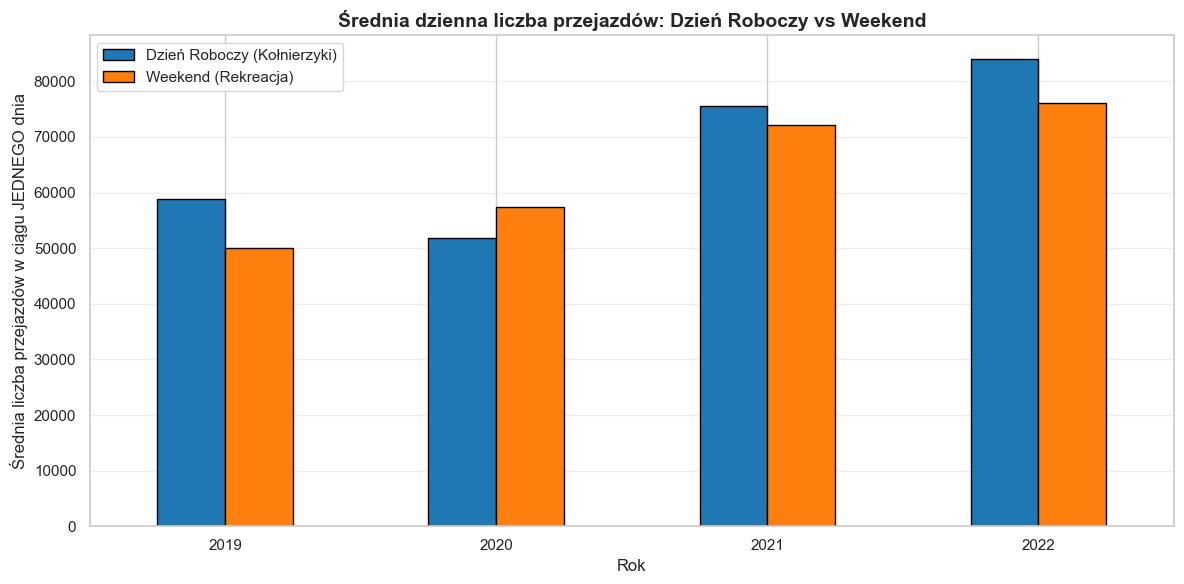

day_type  Dzień Roboczy (Kołnierzyki)  Weekend (Rekreacja)
year                                                      
2019                          58798.0              50058.0
2020                          51868.0              57436.0
2021                          75514.0              72078.0
2022                          84060.0              76025.0


In [20]:
# Liczymy ŚREDNIĄ dzienną liczbę przejazdów dla typu dnia w każdym roku
df_avg = df.groupby(['year', 'day_type'])['total_rides'].mean().unstack()

# Rysujemy porównanie średniej dziennej
plt.figure(figsize=(12, 6))
df_avg.plot(kind='bar', figsize=(12, 6), color=['#1f77b4', '#ff7f0e'], edgecolor='black')

plt.title('Średnia dzienna liczba przejazdów: Dzień Roboczy vs Weekend', fontsize=14, fontweight='bold')
plt.xlabel('Rok', fontsize=12)
plt.ylabel('Średnia liczba przejazdów w ciągu JEDNEGO dnia', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Wyświetlamy suche liczby pod wykresem
print(df_avg.round(0))